In [1]:
# importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [2]:
suction_df = pd.read_csv('./suction_only.csv')
suction_df.columns = ['AOA', 'suction_location', 'suction_slot_size', 'cl', 'cd', 'Re', 'chord_length']
suction_df

,AOA,suction_location,suction_slot_size,cl,cd,Re,chord_length
0,-20.0,53,0.5,-0.65,0.280,1000000,460
1,-19.5,53,0.5,-0.66,0.265,1000000,460
2,-19.0,53,0.5,-0.67,0.250,1000000,460
3,-18.5,53,0.5,-0.68,0.235,1000000,460
4,-18.0,53,0.5,-0.69,0.220,1000000,460
...,...,...,...,...,...,...,...
679,25.5,50,2.0,3.50,0.864,2000000,600
680,26.0,50,2.0,3.45,0.888,2000000,600
681,26.5,50,2.0,3.40,0.912,2000000,600
682,27.0,50,2.0,3.35,0.936,2000000,600


In [3]:
# setting up the data
data_df = suction_df.drop(columns=['cl', 'cd'])
data_df
suction_data = np.array(data_df)
suction_data

array([[-2.00e+01,  5.30e+01,  5.00e-01,  1.00e+06,  4.60e+02],
       [-1.95e+01,  5.30e+01,  5.00e-01,  1.00e+06,  4.60e+02],
       [-1.90e+01,  5.30e+01,  5.00e-01,  1.00e+06,  4.60e+02],
       ...,
       [ 2.65e+01,  5.00e+01,  2.00e+00,  2.00e+06,  6.00e+02],
       [ 2.70e+01,  5.00e+01,  2.00e+00,  2.00e+06,  6.00e+02],
       [ 2.75e+01,  5.00e+01,  2.00e+00,  2.00e+06,  6.00e+02]],
      shape=(684, 5))

In [4]:
#setting up the targets
suction_cl = np.array(suction_df['cl'])
suction_cd = np.array(suction_df['cd'])
# suction_cl

In [5]:
# splitting the data for cl and and cd separately
from sklearn.model_selection import train_test_split

X_train_cl, X_test_cl, y_train_cl, y_test_cl = train_test_split(suction_data, suction_cl, random_state=0)
X_train_cd, X_test_cd, y_train_cd, y_test_cd = train_test_split(suction_data, suction_cd, random_state=0)

# X_train_cd
# X_train_cl

### Data Scaling

In [6]:
# scaling the data
from sklearn.preprocessing import StandardScaler

scaler_cl = StandardScaler().fit(X_train_cl)
scaler_cd = StandardScaler().fit(X_train_cd)
# scaling the cl data

X_train_cl_scaled = scaler_cl.transform(X_train_cl)
X_test_cl_scaled = scaler_cl.transform(X_test_cd)

# scaling the cd data
X_train_cd_scaled = scaler_cd.transform(X_train_cd)
X_test_cd_scaled = scaler_cd.transform(X_test_cd)

# X_train_cd_scaled
# X_train_cl_scaled


### Training the models

In [7]:
from sklearn.neural_network import MLPRegressor

mlp_cl = MLPRegressor(random_state=0,hidden_layer_sizes=(100, 100), max_iter=600).fit(X_train_cl_scaled, y_train_cl)

mlp_cd = MLPRegressor(random_state=0, early_stopping=True, hidden_layer_sizes=(100, 100), max_iter=250).fit(X_train_cd_scaled, y_train_cd)

print("CL prediction accuracy")
print(f"Cl training score: {mlp_cl.score(X_train_cl_scaled, y_train_cl)}")
print(f"Cl Test score: {mlp_cl.score(X_test_cl_scaled, y_test_cl)}")


print("\nCD prediction accuracy")
print(f"Cd training score: {mlp_cd.score(X_train_cd_scaled, y_train_cd)}")
print(f"Cd Test score: {mlp_cd.score(X_test_cd_scaled, y_test_cd)}")



CL prediction accuracy
Cl training score: 0.9954619935391733
Cl Test score: 0.9957990217612452

CD prediction accuracy
Cd training score: 0.9985874128297003
Cd Test score: 0.9976136220430682


### Predicting for all the combinations of injection locations and slot sizes

In [8]:
import itertools

suction_locations = [50, 55, 60, 65, 70, 75, 80]
suction_slot_sizes = [0.5, 1, 1.5, 2, 2.5]
all_geometries = list(itertools.product(
    suction_locations,
    suction_slot_sizes
))

angles_of_attack = np.arange(0, 29, 1)
Re = 2000000
chord_length = 600
output_dict = {
    "AOA" : [],
    "suction_location" : [],
    "suction_slot_size" : [],
    "predicted_cl" : [],
    "predicted_cd" : []
}
for i, geometry in enumerate(all_geometries):
    print(f"Computing for geometry #{i}.......")
    suction_location = geometry[0]
    suction_slot_size = geometry[1]
    for aoa in angles_of_attack:
        # get the results
        print(f"{aoa}", end=',')
        aoa = int(aoa)
        X_input = [[aoa, suction_location, suction_slot_size, Re, chord_length]]
        X_input_scaled = scaler_cl.transform(X_input)
        predicted_cl = float(mlp_cl.predict(X_input_scaled)[0])
        predicted_cd = float(mlp_cd.predict(X_input_scaled)[0])
        
        # store the results
        output_dict["AOA"].append(aoa)
        output_dict['suction_location'].append(suction_location)
        output_dict['suction_slot_size'].append(suction_slot_size)
        output_dict['predicted_cl'].append(predicted_cl)
        output_dict['predicted_cd'].append(predicted_cd)
    
    print(f"\nGeometry {i} complete! ")
        

Computing for geometry #0.......
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,
Geometry 0 complete! 
Computing for geometry #1.......
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,
Geometry 1 complete! 
Computing for geometry #2.......
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,
Geometry 2 complete! 
Computing for geometry #3.......
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,
Geometry 3 complete! 
Computing for geometry #4.......
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,
Geometry 4 complete! 
Computing for geometry #5.......
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,
Geometry 5 complete! 
Computing for geometry #6.......
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,
Geometry 6 complete! 
Computing for geometry #7.......
0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,1

In [9]:
output_dict

{'AOA': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  0,
  1,

In [10]:
output_df = pd.DataFrame(output_dict, index=None)
output_df

,AOA,suction_location,suction_slot_size,predicted_cl,predicted_cd
0,0,50,0.5,0.536753,0.456985
1,1,50,0.5,0.626711,0.464643
2,2,50,0.5,0.716262,0.474014
3,3,50,0.5,0.805793,0.485449
4,4,50,0.5,0.898952,0.496486
...,...,...,...,...,...
1010,24,80,2.5,2.512967,0.764480
1011,25,80,2.5,2.545892,0.791172
1012,26,80,2.5,2.572602,0.818140
1013,27,80,2.5,2.593333,0.845108


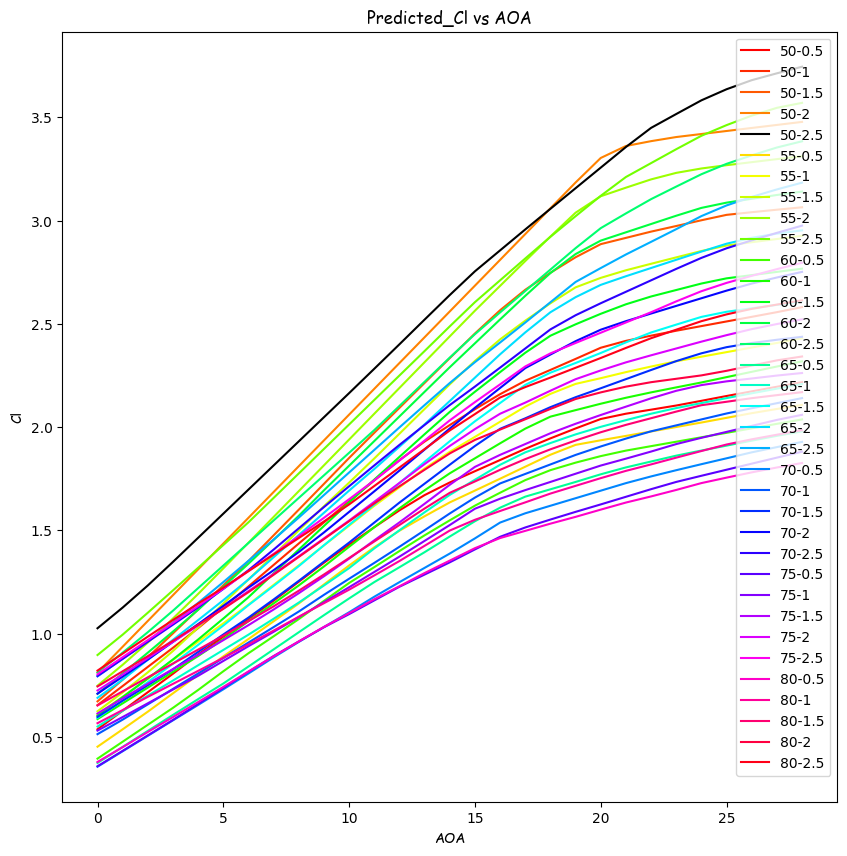

In [11]:
# function that will extract and plot each with a corresponding label

# create a colour map
num_lines = len(all_geometries)
colours = plt.get_cmap('hsv')(np.linspace(0, 1, num_lines))

plt.figure(figsize=(10, 10))

for i, geometry in enumerate(all_geometries):

    # create a condition to extract the data for that geometry
    condition = (output_df.suction_location == geometry[0]) & (output_df.suction_slot_size == geometry[1])

    # create a case dataframe
    case_df = output_df.loc[condition]

    # create a label to store the data for that case
    label = str(geometry[0]) + '-' + str(geometry[1])
    # plot it
    if geometry[0] == 50 and geometry[1] == 2.5:
         plt.plot(case_df.AOA, case_df.predicted_cl, label=label, color='black')
        
    else:
        plt.plot(case_df.AOA, case_df.predicted_cl, label=label, color=colours[i])


plt.title("Predicted_Cl vs AOA", fontname="Comic Sans MS")
plt.xlabel("AOA", fontname="Comic Sans MS")
plt.ylabel("Cl", fontname="Comic Sans MS")
plt.legend()

plt.show()

# 50 - 2.5 is the best configuration

### plotting them together

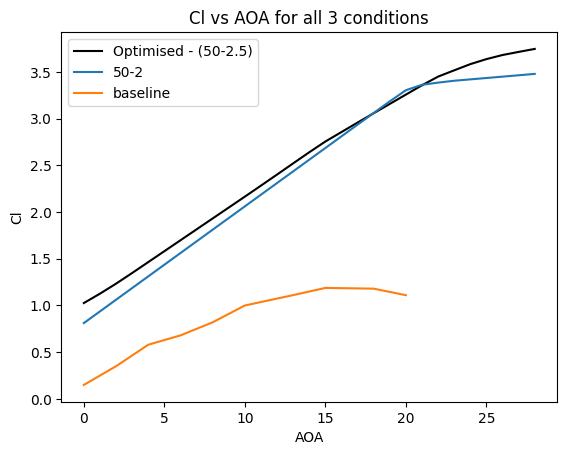

In [12]:
# extracting the optimal configuration to ready it for plotting
optimal_cl_condition = (output_df.suction_location == 50 ) & (output_df.suction_slot_size == 2.5)
optimal_cl_df = output_df.loc[optimal_cl_condition]

# tried condition
sirs_condition = (output_df.suction_location == 50 ) & (output_df.suction_slot_size == 2)
sirs_cl_df = output_df.loc[sirs_condition]
sirs_cl_df

# baseline condition
baseline_df = pd.read_csv('./baseline.csv')
baseline_df.columns = ["AOA", "cl", "cd"]
# baseline_df

# plotting them together
plt.plot(optimal_cl_df.AOA, optimal_cl_df.predicted_cl, label="Optimised - (50-2.5)", color='black')
plt.plot(sirs_cl_df.AOA, sirs_cl_df.predicted_cl, label="50-2")
plt.plot(baseline_df.AOA, baseline_df.cl, label='baseline')

plt.title("Cl vs AOA for all 3 conditions")
plt.xlabel("AOA")
plt.ylabel("Cl")

# plt.grid()
plt.legend()
plt.show()

### Optimising CD for suction Only

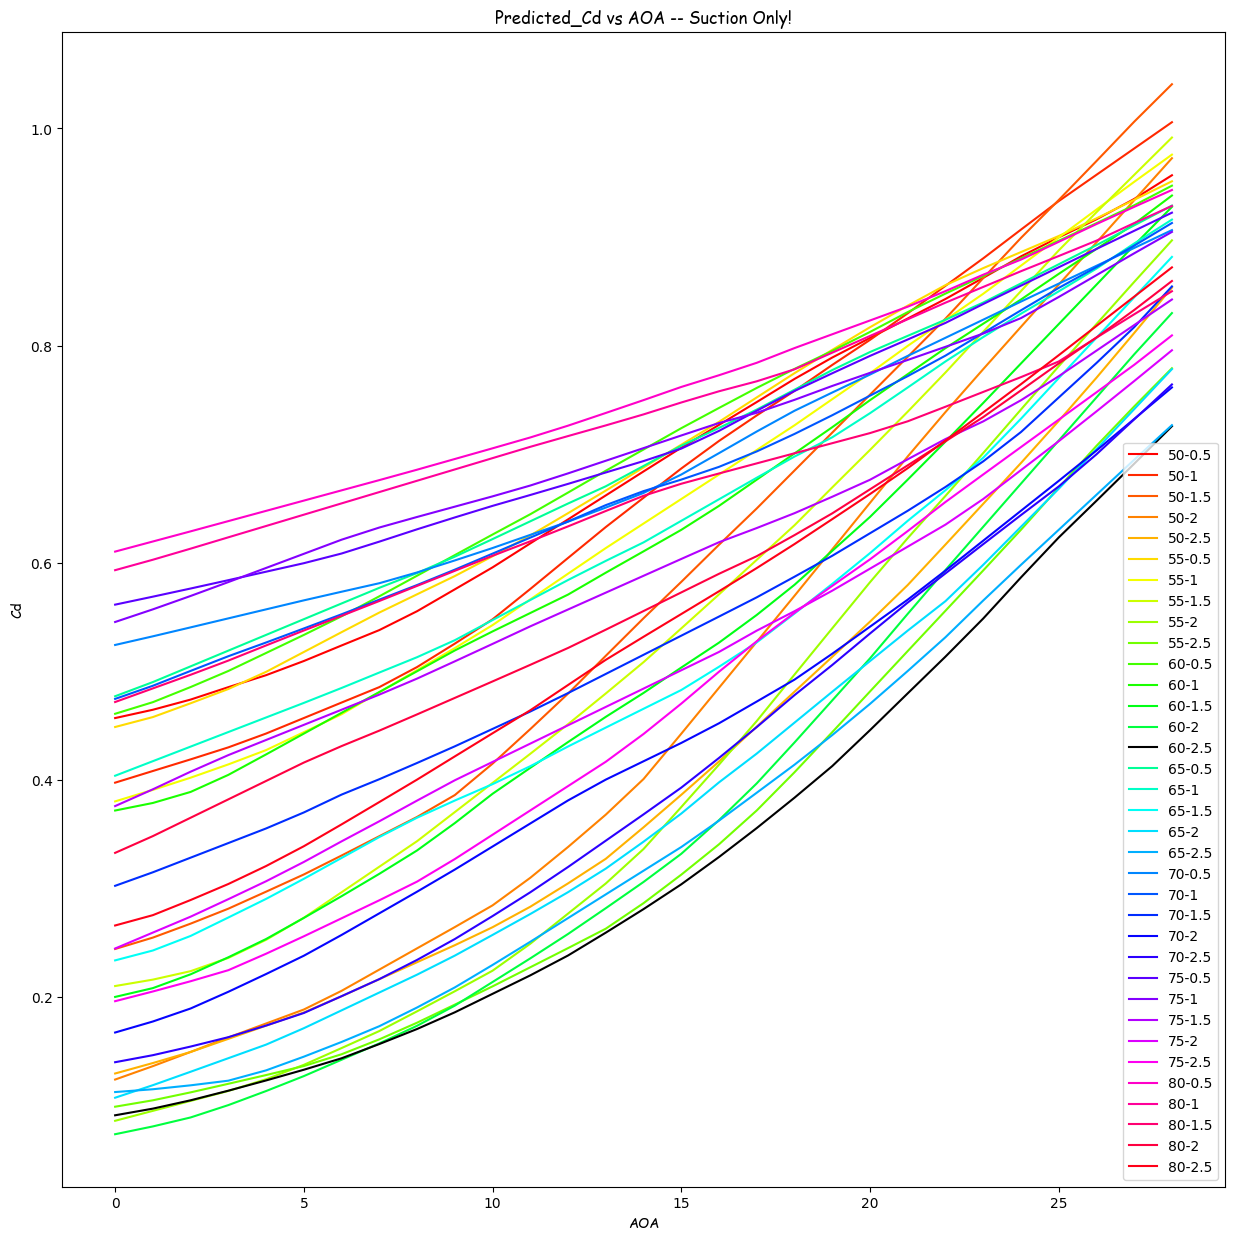

In [13]:
# function that will extract and plot each with a corresponding label

# create a colour map
num_lines = len(all_geometries)
colours = plt.get_cmap('hsv')(np.linspace(0, 1, num_lines))

plt.figure(figsize=(15, 15))

for i, geometry in enumerate(all_geometries):

    # create a condition to extract the data for that geometry
    condition = (output_df.suction_location == geometry[0]) & (output_df.suction_slot_size == geometry[1])

    # create a case dataframe
    case_df = output_df.loc[condition]

    # create a label to store the data for that case
    label = str(geometry[0]) + '-' + str(geometry[1])
    # plot it
    if geometry[0] == 60 and geometry[1] == 2.5:
         plt.plot(case_df.AOA, case_df.predicted_cd, label=label, color='black')
        
    else:
        plt.plot(case_df.AOA, case_df.predicted_cd, label=label, color=colours[i], ms=10)


plt.title("Predicted_Cd vs AOA -- Suction Only!", fontname="Comic Sans MS")
plt.xlabel("AOA", fontname="Comic Sans MS")
plt.ylabel("Cd", fontname="Comic Sans MS")
plt.legend()

plt.show()

# best configuration is 60-2.5

### plotting them together

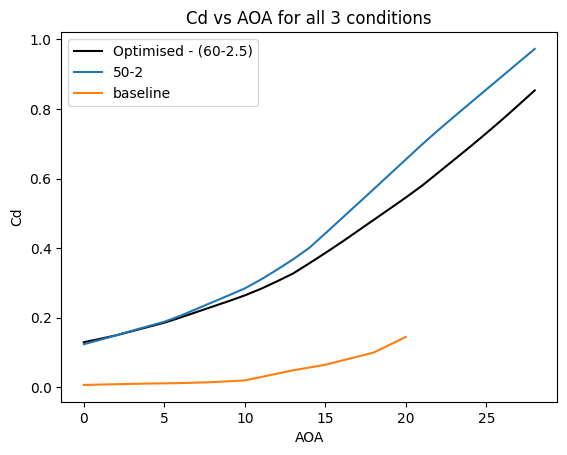

In [14]:
# extracting the optimal configuration to ready it for plotting
optimal_cd_condition = (output_df.suction_location == 50 ) & (output_df.suction_slot_size == 2.5)
optimal_cd_df = output_df.loc[optimal_cd_condition]

# tried condition
sirs_condition = (output_df.suction_location == 50 ) & (output_df.suction_slot_size == 2)
sirs_cd_df = output_df.loc[sirs_condition]
sirs_cd_df

# baseline condition
baseline_df = pd.read_csv('./baseline.csv')
baseline_df.columns = ["AOA", "cl", "cd"]
# baseline_df

# plotting them together
plt.plot(optimal_cd_df.AOA, optimal_cd_df.predicted_cd, label="Optimised - (60-2.5)", color='black')
plt.plot(sirs_cd_df.AOA, sirs_cl_df.predicted_cd, label="50-2")
plt.plot(baseline_df.AOA, baseline_df.cd, label='baseline')

plt.title("Cd vs AOA for all 3 conditions")
plt.xlabel("AOA")
plt.ylabel("Cd")

# plt.grid()
plt.legend()
plt.show()

### Exporting final CSV files

In [15]:
# this is to export the csv files containing the results from the most desirable condition that was obtained from the analysis
# for suction only_ 50-2.5 produced best CL, so we will consider that as the optimised CL
# additionally, we will take the CD for the same condition since we cannot use 2 different configurations at once
# We prioritise the config that gives max CL

In [18]:
# extract and create a new dataframe containing only the optimised data
condition = (output_df.suction_location == 50) & (output_df.suction_slot_size == 2.5) 
optimised_suction_only_df = output_df.loc[condition]
optimised_suction_only_df

# convert to csv the df to csv
optimised_suction_only_df.to_csv("optimised_suc_only.csv", index=False)